# Read data (all 12 csv files)

nyc_taxi csv files are expected to be in the `data/` directory.

## 1. Library Imports


In [2]:
import dataset                          # Data loader
import pandas as pd                     # For the data manipulation
import numpy as np                      # For the numerical operations
import matplotlib.pyplot as plt         # Plots
import seaborn as sns                   # This is for the plots to look better

from xgboost import XGBRegressor        # Make sure to install pip install xgboost
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## Data Loading
We are loading the NYC Yellow Taxi trip records for 2024 using the shared 'dataset.py'.
Because of memory management we are initally loading a subset of months. The 12-month dataset is used for final  model training and evaluation

In [ ]:
# Pulling total data is 4M - things get buggy;
# Using the months of the year but only loading 3 rows to avoid bugs in loading the data
df = dataset.raw(month_start=1, month_end=12)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (41169720, 20)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'month']

First 3 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,month
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,1
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,1
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,1


## The data contains ALL NYC boroughs but we only care about Manhattan thus
###  We use the taxi zone lookup to filter down to Manhattan only


In [4]:
zones = pd.read_csv("../../data/taxi_zone_lookup.csv")

print(zones.head())
print("\nBoroughs available:", zones["Borough"].unique())

# We are getting just the Manhattan zone IDs
manhattan_ids = zones[zones["Borough"] == "Manhattan"]["LocationID"].tolist()
print(f"\nNumber of Manhattan zones: {len(manhattan_ids)}")

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone

Boroughs available: <StringArray>
[          'EWR',        'Queens',         'Bronx',     'Manhattan',
 'Staten Island',      'Brooklyn',       'Unknown',             nan]
Length: 8, dtype: str

Number of Manhattan zones: 69


## Data Cleaning
1. Trips with zero or negative fare amounts are removed as they represent data entry errors
2. Invalid distances which means zero or negative distances are also removed
3. Errors such as the pick-up time occours after the drop off time
4. Rows with missing timestamp are dropped from the table

In [5]:
# We are keeping only Manhattan pickups
df = df[df["PULocationID"].isin(manhattan_ids)]

# Removing rows with invalid fares (negative or zero fare amounts don't make sense)
df = df[df["fare_amount"] > 0]

# Removing the rows with invalid trip distances
df = df[df["trip_distance"] > 0]

# Removing rows where pickup is after dropoff (data error)
df = df[df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]]

# Removing any rows with missing pickup times
df = df.dropna(subset=["tpep_pickup_datetime"])

print("Shape after cleaning:", df.shape)
print("\nAny nulls remaining?")
print(df.isnull().sum())

Shape after cleaning: (35261412, 20)

Any nulls remaining?
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          3249005
trip_distance                  0
RatecodeID               3249005
store_and_fwd_flag       3249005
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     3249005
Airport_fee              3249005
month                          0
dtype: int64


## Temporal Aggregation - Trip-Level to Hourly Demand

So we are using the individual trip records into hourly demand counts per zone.
For each (zone, hour) pair we compute:
- **demand**: the count of pickups — our primary prediction target
- **avg_fare**: mean fare amount — used by the revenue modelling team
- **total_revenue**: sum of total amounts — used by the revenue modelling team


This helps in reducing the approx. 36 million raw rows to around 600,000 structured observations.

In [7]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

hourly = df.groupby(["pickup_hour", "PULocationID"]).agg(
    demand       = ("PULocationID", "count"),       # number of rides = demand
    avg_fare     = ("fare_amount", "mean"),          # average fare per ride
    total_revenue= ("total_amount", "sum")           # total reve  nue in that zone/hour
).reset_index()

print("Shape of aggregated data:", hourly.shape)
print("\nSample:")
hourly.head(5)

Shape of aggregated data: (507576, 5)

Sample:


,pickup_hour,PULocationID,demand,avg_fare,total_revenue
0,2002-12-31 22:00:00,50,1,10.0,18.00
1,2002-12-31 22:00:00,170,2,19.8,56.22
2,2002-12-31 22:00:00,237,1,7.9,11.90
3,2002-12-31 22:00:00,246,1,7.2,11.20
4,2002-12-31 23:00:00,162,1,45.7,70.97


## Feature Engineering

Raw datetime objects cannot be directly consumed my machine learning models. 
Thus we are using temporal features that capture known patterns in urban mobility

- **hour**: Captures intra-day demand cycles (e.g. morning/evening rush hours)
- **day_of_week**: Captures weekly patterns (e.g. higher weekend leisure travel)
- **month**: Captures seasonal variation across the year
- **is_weekend**: Binary flag distinguishing weekday commuter demand from weekend patterns

Additionally, we engineer **lag features** — a standard technique in time-series 
forecasting that provides the model with recent historical context:

- **lag_1h**: Demand one hour prior (captures short-term momentum)
- **lag_24h**: Demand at the same hour the previous day (captures daily cycles)
- **lag_168h**: Demand at the same hour the previous week (captures weekly cycles)

Rows with missing lag values (the initial observations per zone) are dropped to 
ensure model training is performed on complete feature vectors.

In [8]:
# Machine learning models can't use raw datetime objects
# We need to extract meaningful TIME FEATURES from the pickup hour

hourly = hourly.sort_values(["PULocationID", "pickup_hour"]).reset_index(drop=True)

# Basic time features
hourly["hour"]        = hourly["pickup_hour"].dt.hour         # 0-23 (rush hour vs quiet)
hourly["day_of_week"] = hourly["pickup_hour"].dt.dayofweek    # 0=Monday, 6=Sunday
hourly["month"]       = hourly["pickup_hour"].dt.month        # 1-12 (seasonal effects)
hourly["is_weekend"]  = hourly["day_of_week"].isin([5, 6]).astype(int)  # 1 if Sat/Sun

# Lag features - what was demand in the SAME ZONE in the previous hours?
# These are very powerful because demand is correlated over time
hourly["demand_lag_1h"]  = hourly.groupby("PULocationID")["demand"].shift(1)   # 1 hour ago
hourly["demand_lag_24h"] = hourly.groupby("PULocationID")["demand"].shift(24)  # same hour yesterday
hourly["demand_lag_168h"]= hourly.groupby("PULocationID")["demand"].shift(168) # same hour last week

# Drop rows where lag features are NaN (first few rows of each zone won't have history)
hourly = hourly.dropna()

print("Shape after feature engineering:", hourly.shape)
print("\nFeatures created:")
hourly.head(3)

Shape after feature engineering: (496484, 12)

Features created:


,pickup_hour,PULocationID,demand,avg_fare,total_revenue,hour,day_of_week,month,is_weekend,demand_lag_1h,demand_lag_24h,demand_lag_168h
168,2024-01-10 09:00:00,4,5,18.112,120.53,9,2,1,0,4.0,3.0,22.0
169,2024-01-10 10:00:00,4,2,19.285,55.88,10,2,1,0,5.0,4.0,26.0
170,2024-01-10 11:00:00,4,5,18.400,121.15,11,2,1,0,2.0,1.0,31.0


## Train/Test Split

In [9]:
# IMPORTANT: We split by TIME, not randomly!
# If we split randomly, we might "leak" future data into training (cheating)
# Instead: train on Jan data, test on Feb data

split_date = "2024-11-01"

train = hourly[hourly["pickup_hour"] < split_date]
test  = hourly[hourly["pickup_hour"] >= split_date]

# Define which columns are FEATURES (inputs) vs TARGET (what we predict)
features = [
    "hour",           # time of day
    "day_of_week",    # day of week
    "month",          # month of year
    "is_weekend",     # weekend flag
    "PULocationID",   # which zone
    "demand_lag_1h",  # demand 1 hour ago
    "demand_lag_24h", # demand 24 hours ago
    "demand_lag_168h" # demand 1 week ago
]

target = "demand"  # what we're predicting

X_train = train[features]
y_train = train[target]

X_test  = test[features]
y_test  = test[target]

print(f"Training rows:  {len(X_train)}")
print(f"Test rows:      {len(X_test)}")

Training rows:  411533
Test rows:      84951


## Model Training — XGBoost Regressor

In [10]:
# XGBoost = Extreme Gradient Boosting
# It builds many decision trees sequentially, each one correcting the errors of the last
# It's the industry standard for tabular data like this

model = XGBRegressor(
    n_estimators  = 300,    # number of trees to build
    learning_rate = 0.05,   # how much each tree corrects the previous (smaller = more careful)
    max_depth     = 6,      # how deep each tree can go (controls complexity)
    random_state  = 42      # for reproducibility
)

print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Done!")

Training XGBoost model...
Done!


## Model Evaluation

In [11]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate error metrics
mae  = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("=== XGBoost Demand Model Results ===")
print(f"MAE  (Mean Absolute Error):  {mae:.2f} rides per hour per zone")
print(f"RMSE (Root Mean Sq. Error):  {rmse:.2f} rides per hour per zone")
print()
print("Interpretation:")
print(f"  On average, our predictions are off by ~{mae:.1f} rides per hour per zone")

=== XGBoost Demand Model Results ===
MAE  (Mean Absolute Error):  11.25 rides per hour per zone
RMSE (Root Mean Sq. Error):  19.70 rides per hour per zone

Interpretation:
  On average, our predictions are off by ~11.2 rides per hour per zone


## Feature Importance Analysis

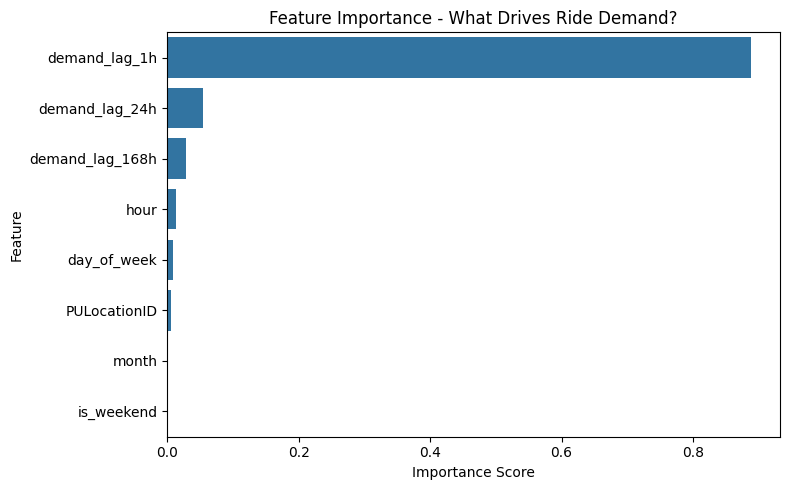

           feature  importance
5    demand_lag_1h    0.887933
6   demand_lag_24h    0.053801
7  demand_lag_168h    0.028289
0             hour    0.014189
1      day_of_week    0.008271
4     PULocationID    0.006164
2            month    0.001353
3       is_weekend    0.000000


In [12]:
# XGBoost can tell us WHICH FEATURES mattered most for predictions
# This is very useful for the report - tells the Operations Manager what drives demand

importance = pd.DataFrame({
    "feature":   features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="importance", y="feature")
plt.title("Feature Importance - What Drives Ride Demand?")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(importance)

## Predicted vs Actual Demand Visualisation

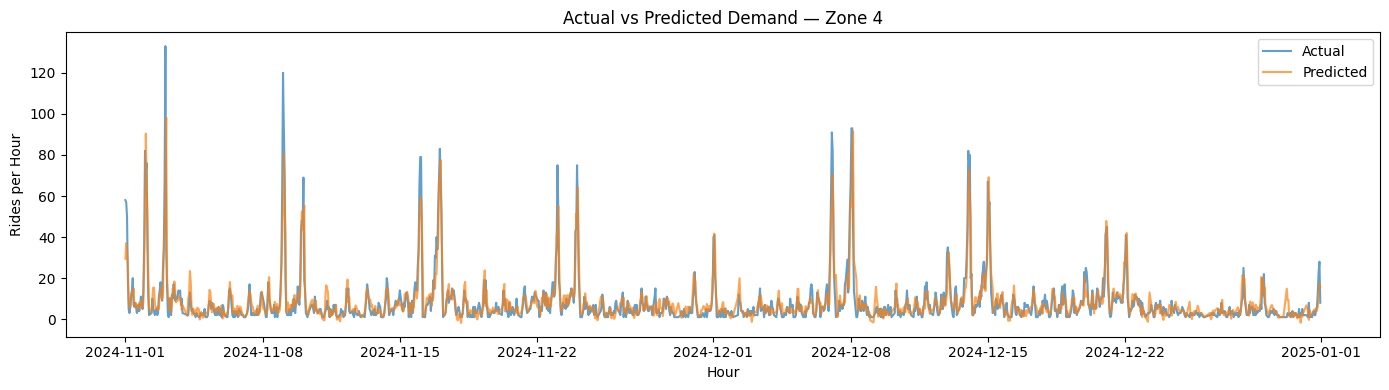

In [13]:
# Plot actual vs predicted demand for a visual sense of model quality
# We pick one zone to keep the chart readable

sample_zone = manhattan_ids[0]  # just pick the first Manhattan zone
mask = X_test["PULocationID"] == sample_zone

plt.figure(figsize=(14, 4))
plt.plot(test[mask]["pickup_hour"], y_test[mask].values,   label="Actual",    alpha=0.7)
plt.plot(test[mask]["pickup_hour"], predictions[mask],      label="Predicted", alpha=0.7)
plt.title(f"Actual vs Predicted Demand — Zone {sample_zone}")
plt.xlabel("Hour")
plt.ylabel("Rides per Hour")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Save the cleaned aggregated data for the revenue team to use
hourly.to_csv("../../data/hourly_aggregated.csv", index=False)
print("Saved! Shape:", hourly.shape)

Saved! Shape: (496484, 12)


In [15]:
import os
os.makedirs("../../data/processed", exist_ok=True)
hourly.to_csv("../../data/processed/hourly_aggregated.csv", index=False)
print("Saved! Shape:", hourly.shape)

Saved! Shape: (496484, 12)
